In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels as sm
import sklearn
import yfinance as yf
import seaborn as sns

In [3]:
ticker = "^NSEI"

nifty = yf.download(
    ticker,
    start="2015-01-01",
    end=None,
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [4]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [5]:
file_path = "data/nifty50.csv"
nifty.to_csv(file_path)


In [7]:
 pd.read_csv("data/nifty50.csv")

,Price,Close,High,Low,Open,Volume
0,Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,8395.4501953125,8410.599609375,8288.7001953125,8288.7001953125,101900
3,2015-01-05,8378.400390625,8445.599609375,8363.900390625,8407.9501953125,118200
4,2015-01-06,8127.35009765625,8327.849609375,8111.35009765625,8325.2998046875,172800
...,...,...,...,...,...,...
2837,2026-07-13,24211.0,24259.80078125,24000.19921875,24039.400390625,322700
2838,2026-07-14,24052.05078125,24157.099609375,24023.69921875,24068.0,355800
2839,2026-07-15,24078.5,24220.349609375,24010.55078125,24085.849609375,306900
2840,2026-07-16,24072.75,24186.5,24050.0,24142.099609375,264300


In [8]:
len(nifty)

2840

In [9]:
nifty.shape

(2840, 5)

In [10]:
nifty.columns

MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])

In [11]:
nifty.dtypes

Price   Ticker
Close   ^NSEI     float64
High    ^NSEI     float64
Low     ^NSEI     float64
Open    ^NSEI     float64
Volume  ^NSEI       int64
dtype: object

In [13]:
nifty.isnull().sum()

Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Open    ^NSEI     0
Volume  ^NSEI     0
dtype: int64

In [15]:
nifty.describe()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
count,2840.000000,2840.000000,2840.000000,2840.000000,2.840000e+03
mean,14981.619975,15059.313588,14901.018288,14990.653365,3.262556e+05
std,5963.322504,5986.165191,5939.352584,5962.602467,1.868335e+05
min,6970.600098,7034.200195,6825.799805,7023.649902,0.000000e+00
25%,9962.100342,10001.712158,9899.462402,9959.737305,2.035250e+05
50%,12223.100098,12262.024902,12162.875000,12215.099609,2.725500e+05
75%,19473.075195,19557.074707,19413.250000,19503.486816,3.946000e+05
max,26328.550781,26373.199219,26210.050781,26333.699219,1.811000e+06


In [17]:
nifty.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2840 entries, 2015-01-02 to 2026-07-17
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^NSEI)   2840 non-null   float64
 1   (High, ^NSEI)    2840 non-null   float64
 2   (Low, ^NSEI)     2840 non-null   float64
 3   (Open, ^NSEI)    2840 non-null   float64
 4   (Volume, ^NSEI)  2840 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 133.1 KB


In [20]:
libraries()

NameError: name 'libraries' is not defined

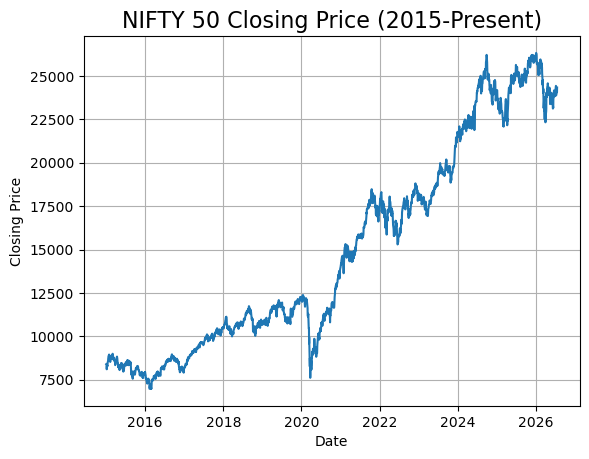

In [22]:
plt.plot(nifty.index, nifty["Close"])

plt.title("NIFTY 50 Closing Price (2015-Present)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.savefig("figures/nifty_close_price.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
nifty["MA_30"] = nifty["Close"].rolling(window=30).mean()
nifty["MA_90"] = nifty["Close"].rolling(window=90).mean()

In [24]:
nifty.head()

Price,Close,High,Low,Open,Volume,MA_30,MA_90
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,
Date,,,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,NaN,NaN
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,NaN,NaN
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,NaN,NaN
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,NaN,NaN


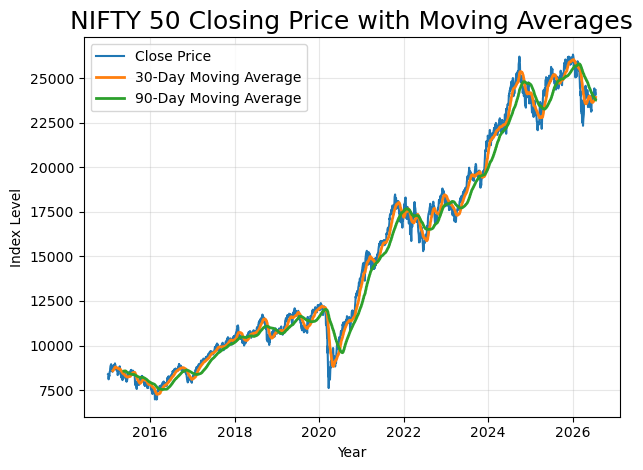

In [25]:
plt.plot(
    nifty.index,
    nifty["Close"],
    label="Close Price",
    linewidth=1.5
)

plt.plot(
    nifty.index,
    nifty["MA_30"],
    label="30-Day Moving Average",
    linewidth=2
)

plt.plot(
    nifty.index,
    nifty["MA_90"],
    label="90-Day Moving Average",
    linewidth=2
)

plt.title("NIFTY 50 Closing Price with Moving Averages", fontsize=18)

plt.xlabel("Year")
plt.ylabel("Index Level")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/moving_averages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
nifty["Daily Returns"] = nifty["Close"].pct_change()

In [28]:
nifty.head()

Price,Close,High,Low,Open,Volume,MA_30,MA_90,Daily Returns
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,
Date,,,,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN,NaN
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,NaN,NaN,-0.002031
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,NaN,NaN,-0.029964
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,NaN,NaN,-0.003107
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,NaN,NaN,0.016354


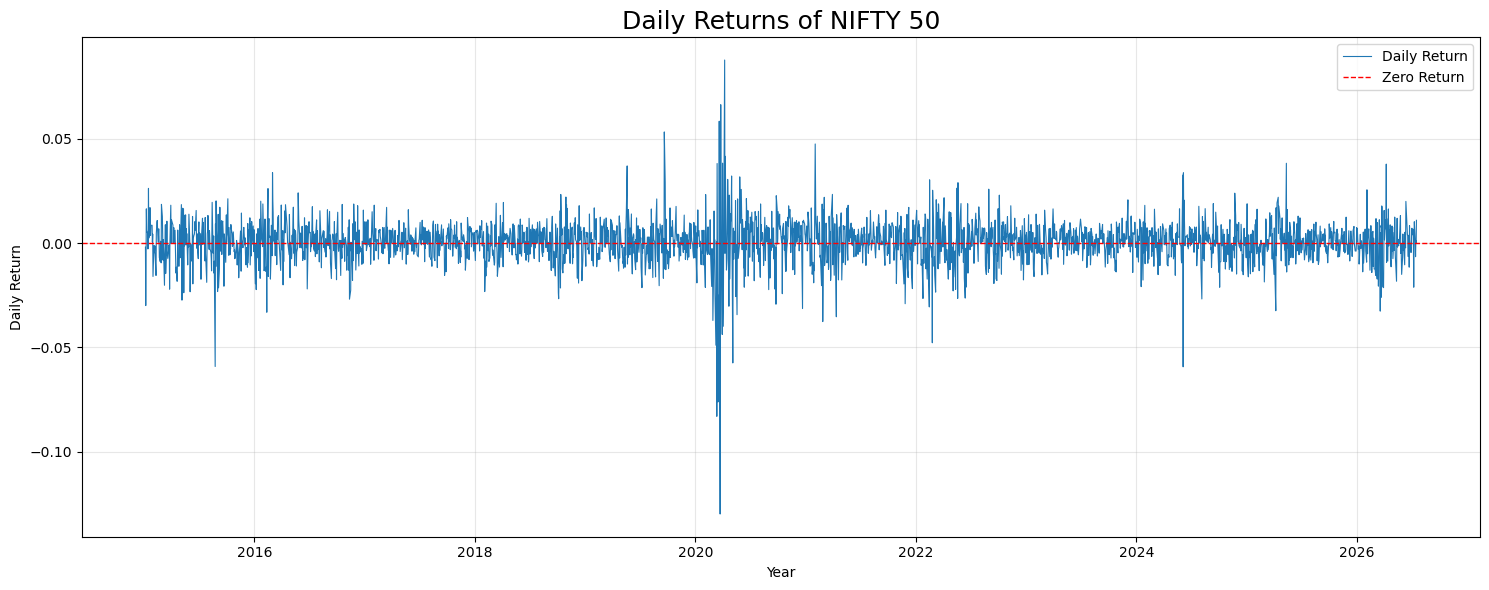

In [30]:
plt.figure(figsize=(15,6))

plt.plot(
    nifty.index,
    nifty["Daily Returns"],
    linewidth=0.8,
    label="Daily Return"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Zero Return"
)

plt.title("Daily Returns of NIFTY 50", fontsize=18)

plt.xlabel("Year")
plt.ylabel("Daily Return")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/daily_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
returns = nifty["Daily Returns"].dropna()

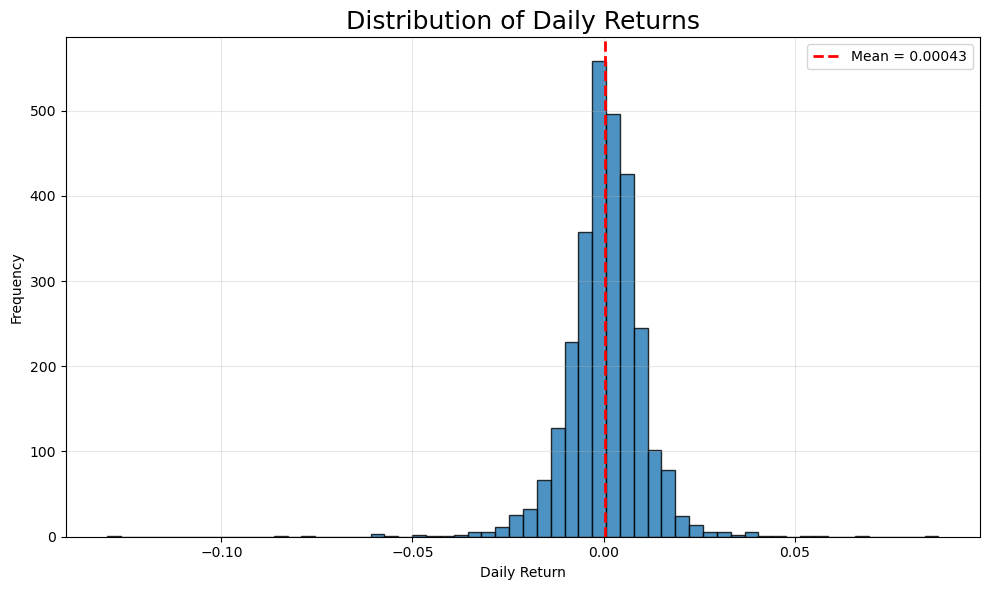

In [48]:
plt.figure(figsize=(10,6))

plt.hist(
    returns,
    bins=60,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    returns.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {returns.mean():.5f}"
)

plt.title("Distribution of Daily Returns", fontsize=18)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
nifty.head()

Price,Close,High,Low,Open,Volume,MA_30,MA_90,Daily Returns
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,
Date,,,,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN,NaN,NaN
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,NaN,NaN,-0.002031
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,NaN,NaN,-0.029964
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,NaN,NaN,-0.003107
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,NaN,NaN,0.016354


In [63]:
nifty["RV_30"] = (
    nifty["Daily Returns"]
    .rolling(window=30)
    .std()
)

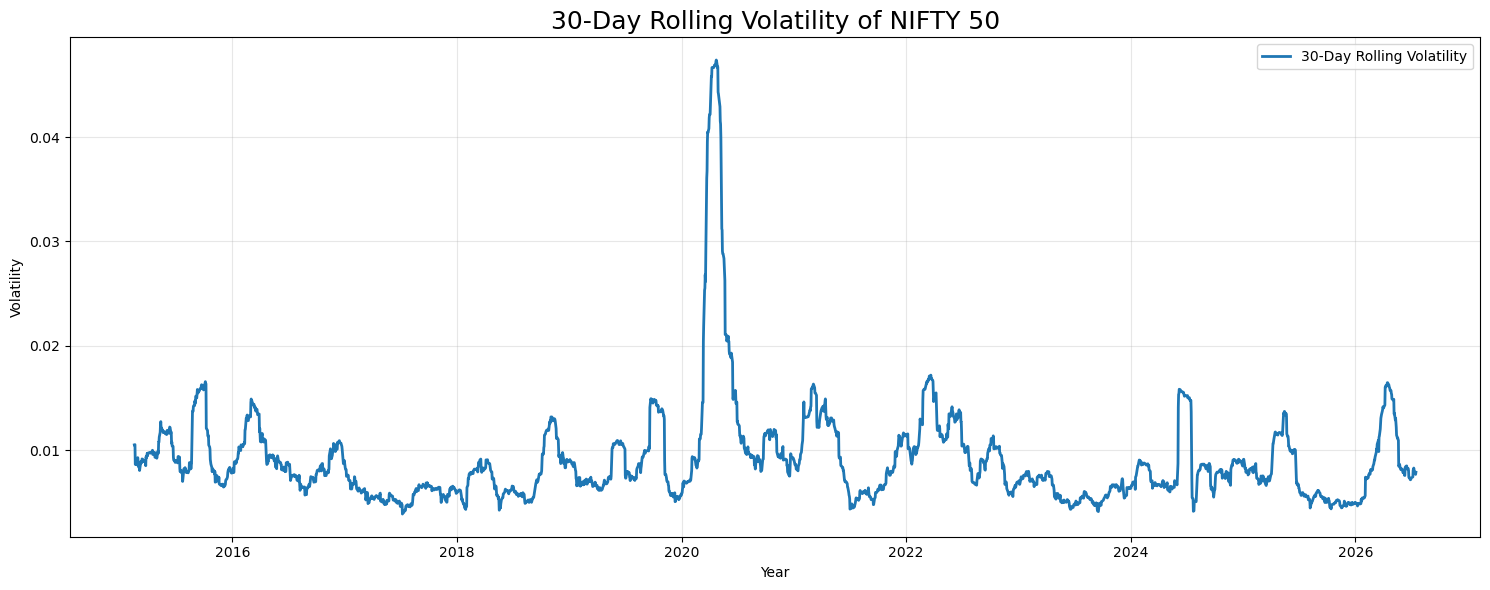

In [64]:
plt.figure(figsize=(15,6))

plt.plot(
    nifty.index,
    nifty["RV_30"],
    linewidth=2,
    label="30-Day Rolling Volatility"
)

plt.title("30-Day Rolling Volatility of NIFTY 50", fontsize=18)

plt.xlabel("Year")
plt.ylabel("Volatility")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/rolling_volatility_30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
nifty.RV_30.describe()

count    2810.000000
mean        0.008990
std         0.004899
min         0.003897
25%         0.006288
50%         0.007933
75%         0.010251
max         0.047377
Name: RV_30, dtype: float64

In [66]:
nifty.nlargest(
    10,
    "RV_30"
)[["Close", "Daily Returns", "RV_30"]]

Price,Close,Daily Returns,RV_30
Ticker,^NSEI,,
Date,,,
2020-04-23,9313.900391,0.013780,0.047377
2020-04-24,9154.400391,-0.017125,0.047288
2020-04-22,9187.299805,0.022919,0.047261
2020-04-21,8981.450195,-0.030275,0.046953
2020-04-20,9261.849609,-0.000529,0.046897
2020-04-17,9266.750000,0.030463,0.046889
2020-04-16,8992.799805,0.007563,0.046739
2020-04-28,9380.900391,0.010622,0.046723


In [74]:
price_data = nifty[
    ["Open", "High", "Low", "Close", "Daily Returns", "RV_30" ,"MA_30","MA_90"]
]

In [75]:
corr_matrix = price_data.corr()

corr_matrix

,Price,Open,High,Low,Close,Daily Returns,RV_30,MA_30,MA_90
,Ticker,^NSEI,^NSEI,^NSEI,^NSEI,,,,
Price,Ticker,,,,,,,,
Open,^NSEI,1.000000,0.999924,0.999887,0.999805,-0.004458,-0.172933,0.997266,0.991323
High,^NSEI,0.999924,1.000000,0.999862,0.999909,0.001196,-0.169743,0.997478,0.991707
Low,^NSEI,0.999887,0.999862,1.000000,0.999911,0.003569,-0.176185,0.996983,0.990953
Close,^NSEI,0.999805,0.999909,0.999911,1.000000,0.009738,-0.172844,0.997147,0.991257
Daily Returns,,-0.004458,0.001196,0.003569,0.009738,1.000000,0.025342,-0.011290,-0.013060
RV_30,,-0.172933,-0.169743,-0.176185,-0.172844,0.025342,1.000000,-0.159785,-0.114064
MA_30,,0.997266,0.997478,0.996983,0.997147,-0.011290,-0.159785,1.000000,0.996021
MA_90,,0.991323,0.991707,0.990953,0.991257,-0.013060,-0.114064,0.996021,1.000000


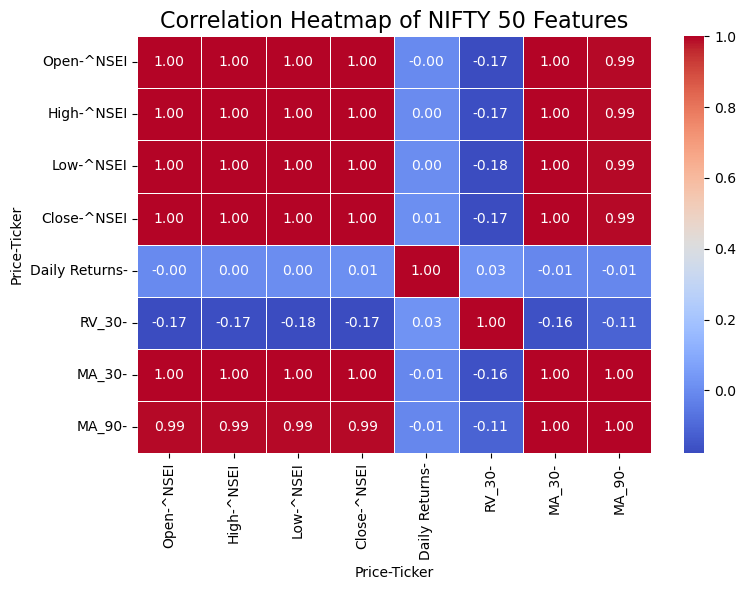

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of NIFTY 50 Features",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()